# Logistic Regression Model

For this notebook, I used the final 18-feature files and trained a logistic regression model for the Chagas ECG project.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

/Users/rmhsh8/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Load the final processed data

These are the final filtered CSVs from Khushleen's feature selection work.

In [2]:
data_dir = Path("processed_data")

train_path = data_dir / "train_final.csv"
val_path = data_dir / "val_final.csv"
test_path = data_dir / "test_final.csv"

print("Train file exists:", train_path.exists())
print("Validation file exists:", val_path.exists())
print("Test file exists:", test_path.exists())

Train file exists: True
Validation file exists: True
Test file exists: True


In [3]:
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)

train.head()

Train shape: (7746, 19)
Validation shape: (2584, 19)


,age,is_male,P_wave_duration_mean,P_wave_duration_std,PR_interval_mean,PR_interval_std,PR_segment_mean,PR_segment_std,QRS_duration_mean,QRS_duration_std,QT_interval_mean,QT_interval_std,ST_segment_mean,ST_segment_std,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_pNN50,target
0,-0.080067,-0.787935,-0.841006,-0.055135,1.089002,0.918455,1.332512,0.813291,-0.763211,-0.812053,0.201465,-0.630556,0.077558,-0.351457,0.946333,0.328705,-0.010365,1.386769,0
1,-1.191728,-0.787935,0.873540,-0.534451,0.366340,-0.757167,0.026520,-0.935958,-0.944048,-0.864915,0.020317,-0.806844,0.295670,-0.639444,0.672048,-0.043469,-0.208611,0.549509,0
2,-0.858230,1.269141,0.772142,-1.105336,0.294966,-0.833143,-0.003735,-0.984452,-0.775267,-0.795702,-0.018980,-0.771288,-0.039706,-0.865024,0.564292,-0.270677,-0.372043,-0.329613,0
3,0.753680,-0.787935,0.142246,-0.352941,-0.287922,-0.245758,-0.323090,-0.066711,0.534796,0.102527,0.171114,-0.353349,0.253455,0.068981,-0.308943,-0.508589,-0.483267,-0.706380,0
4,1.198344,1.269141,-0.687373,-0.249492,0.223592,-0.501063,0.461290,-0.524668,-0.413593,-0.444668,-1.675512,1.929814,-1.138082,2.036125,-0.123381,-0.196938,-0.380236,0.047154,0


The files loaded correctly. The training set has 7,746 rows and the validation set has 2,584 rows. Each file has the 18 selected predictors plus the target column, so this matches the feature set we described in the milestone.

## Check columns and target balance

In [4]:
print("Train columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

Train columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']

Validation columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']


In [5]:
print("Train target counts:")
print(train["target"].value_counts().sort_index())

print("\nValidation target counts:")
print(validation["target"].value_counts().sort_index())

print("\nTrain positive rate:", round(train["target"].mean(), 3))
print("Validation positive rate:", round(validation["target"].mean(), 3))

Train target counts:
target
0    3885
1    3861
Name: count, dtype: int64

Validation target counts:
target
0    1291
1    1293
Name: count, dtype: int64

Train positive rate: 0.498
Validation positive rate: 0.5


The train and validation sets are both basically 50/50 between negative and positive Chagas exams. Because of that, accuracy is useful, but I still want to look at precision, recall, F1, ROC-AUC, and the confusion matrix too.

## Split features and target

Here I separated the predictors from the target column. I also removed ID columns just in case they were still included, because those should not be used as model features.

In [6]:
# Remove the target and any ID columns from the model inputs.
drop_cols = ["target", "exam_id", "patient_id"]

feature_cols = [
    col for col in train.columns
    if col not in drop_cols
]

X_train = train[feature_cols]
y_train = train["target"]

X_val = validation[feature_cols]
y_val = validation["target"]

X_train_np = X_train.astype("float32").to_numpy()
X_val_np = X_val.astype("float32").to_numpy()
y_train_np = y_train.astype("float32").to_numpy()
y_val_np = y_val.astype("float32").to_numpy()

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 18
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50']


In [7]:
print("Missing values in training features:", X_train.isna().sum().sum())
print("Missing values in validation features:", X_val.isna().sum().sum())

Missing values in training features: 0
Missing values in validation features: 0


There are 18 features and no missing values left in the train or validation sets. That means I do not need to do any extra imputation here before running logistic regression.

## Baseline model

I included the baseline again so I can compare logistic regression against a simple model that does not really learn from the ECG features.

In [8]:
majority_class = y_train.value_counts().idxmax()

baseline_pred = np.repeat(majority_class, len(y_val))
baseline_prob = np.repeat(y_train.mean(), len(y_val))

baseline_results = {
    "model": "Baseline",
    "C": np.nan,
    "accuracy": accuracy_score(y_val, baseline_pred),
    "precision": precision_score(y_val, baseline_pred, zero_division=0),
    "recall": recall_score(y_val, baseline_pred, zero_division=0),
    "f1": f1_score(y_val, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, baseline_prob)
}

baseline_results

{'model': 'Baseline',
 'C': nan,
 'accuracy': 0.4996130030959752,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

The baseline is not very useful. It gets about 50% accuracy because the classes are balanced, but it misses every positive case. That is why the precision, recall, and F1-score are all 0. Logistic regression needs to do better than this.

## Try logistic regression with different C values

The `C` value controls how much regularization the model uses. I tried a few values to see which one worked best on the validation set.

In [9]:
def build_logistic_model(input_dim, c):
    l2_strength = 1 / (c * len(X_train_np))

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            kernel_regularizer=tf.keras.regularizers.l2(l2_strength)
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy"
    )

    return model


results = [baseline_results]
trained_models = {}

# Trying a few regularization settings.
c_values = [0.01, 0.1, 1, 10, 100]

for c in c_values:
    tf.random.set_seed(42)

    model = build_logistic_model(
        input_dim=X_train_np.shape[1],
        c=c
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_np,
        y_train_np,
        validation_data=(X_val_np, y_val_np),
        epochs=300,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop]
    )

    prob = model.predict(X_val_np, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    results.append({
        "model": "Logistic Regression",
        "C": c,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, prob)
    })

    trained_models[c] = model

results_df = pd.DataFrame(results)
results_df

,model,C,accuracy,precision,recall,f1,roc_auc
0,Baseline,NaN,0.499613,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.01,0.625774,0.634711,0.593968,0.613664,0.691274
2,Logistic Regression,0.10,0.627709,0.635545,0.600155,0.617343,0.691615
3,Logistic Regression,1.00,0.627322,0.634804,0.600928,0.617402,0.691646
4,Logistic Regression,10.00,0.624226,0.632184,0.595514,0.613301,0.691453
5,Logistic Regression,100.00,0.626161,0.633907,0.598608,0.615752,0.691456


In [10]:
results_df.sort_values("roc_auc", ascending=False)

,model,C,accuracy,precision,recall,f1,roc_auc
3,Logistic Regression,1.00,0.627322,0.634804,0.600928,0.617402,0.691646
2,Logistic Regression,0.10,0.627709,0.635545,0.600155,0.617343,0.691615
5,Logistic Regression,100.00,0.626161,0.633907,0.598608,0.615752,0.691456
4,Logistic Regression,10.00,0.624226,0.632184,0.595514,0.613301,0.691453
1,Logistic Regression,0.01,0.625774,0.634711,0.593968,0.613664,0.691274
0,Baseline,NaN,0.499613,0.000000,0.000000,0.000000,0.500000


All of the logistic regression models are compared against the baseline using the same validation metrics. I used ROC-AUC to pick the best validation model because it shows how well the model separates positive and negative cases across different thresholds.

## Pick the best validation model

For the logistic regression model, I chose the best `C` value based on validation ROC-AUC. I used ROC-AUC because it looks at how well the model separates positive and negative cases across different thresholds.

In [11]:
# Pick the logistic regression model with the best validation ROC-AUC.
logistic_results = results_df[results_df["model"] == "Logistic Regression"].copy()

best_row = logistic_results.sort_values("roc_auc", ascending=False).iloc[0]
best_c = best_row["C"]

print("Best C:", best_c)
print(best_row)

Best C: 1.0
model        Logistic Regression
C                            1.0
accuracy                0.627322
precision               0.634804
recall                  0.600928
f1                      0.617402
roc_auc                 0.691646
Name: 3, dtype: object


The best logistic regression model is the one with the highest validation ROC-AUC. This is a better comparison than accuracy alone because the goal is not just to predict the majority class, but to separate Chagas-positive and Chagas-negative exams better than the baseline.

In [12]:
best_model = trained_models[best_c]

best_prob = best_model.predict(X_val_np, verbose=0).ravel()
best_pred = (best_prob >= 0.5).astype(int)

best_metrics = {
    "accuracy": accuracy_score(y_val, best_pred),
    "precision": precision_score(y_val, best_pred, zero_division=0),
    "recall": recall_score(y_val, best_pred, zero_division=0),
    "f1": f1_score(y_val, best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, best_prob)
}

best_metrics

{'accuracy': 0.6273219814241486,
 'precision': 0.6348039215686274,
 'recall': 0.6009280742459396,
 'f1': 0.6174016686531585,
 'roc_auc': np.float64(0.6916462534663501)}

## Confusion matrix

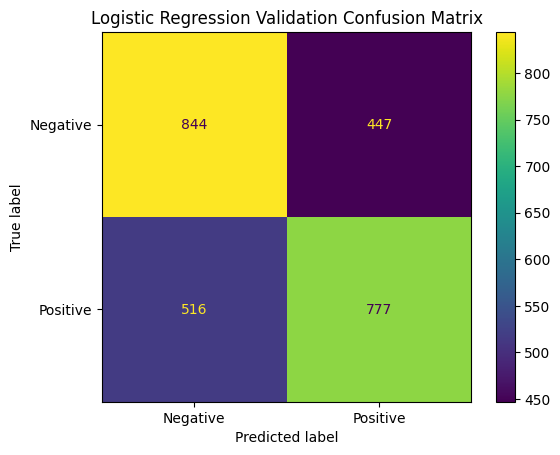

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_pred,
    display_labels=["Negative", "Positive"]
)

plt.title("Logistic Regression Validation Confusion Matrix")
plt.show()

The confusion matrix shows whether the model is actually predicting both classes. This is important because the baseline got around 50% accuracy but missed every positive case. Here, I want to see how many positive cases the model catches and how many negative cases it incorrectly flags.

## ROC curve

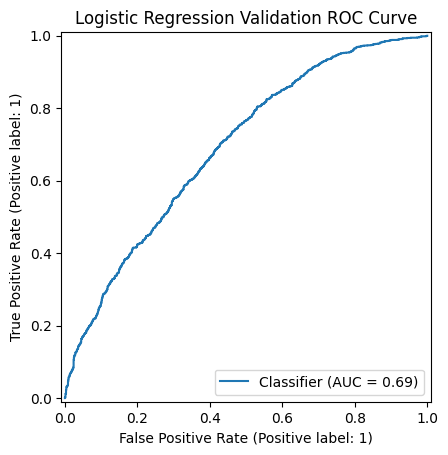

In [14]:
RocCurveDisplay.from_predictions(y_val, best_prob)

plt.title("Logistic Regression Validation ROC Curve")
plt.show()

The ROC curve shows how well the model separates the two classes across different thresholds. A curve closer to the top-left corner is better, while a value near 0.50 would mean the model is close to guessing.

## Coefficients

I also checked the logistic regression coefficients because this model is easier to interpret than something like a random forest. Since the features were already scaled, the larger coefficient values show which features affected the model more.

In [15]:
weights, bias = best_model.layers[0].get_weights()

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": weights.ravel()
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient,abs_coefficient
4,PR_interval_mean,0.482108,0.482108
16,HRV_RMSSD,0.419720,0.419720
13,ST_segment_std,0.397888,0.397888
12,ST_segment_mean,0.395529,0.395529
10,QT_interval_mean,-0.340360,0.340360
0,age,0.316936,0.316936
8,QRS_duration_mean,0.310510,0.310510
2,P_wave_duration_mean,-0.265725,0.265725
6,PR_segment_mean,-0.237732,0.237732
17,HRV_pNN50,-0.202711,0.202711


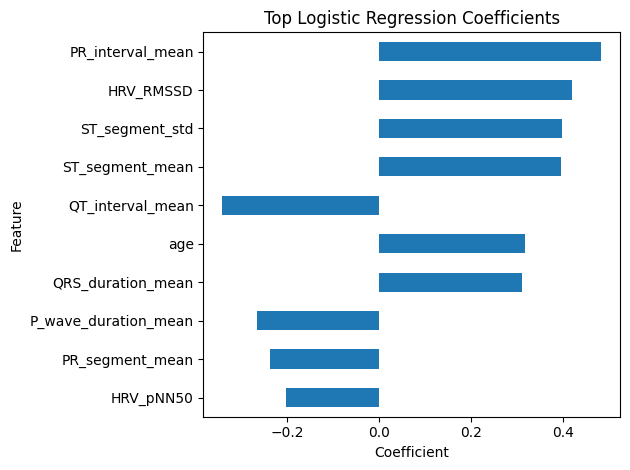

In [16]:
coef_df.head(10).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The largest absolute coefficients show which features had the biggest effect in the logistic regression model. I am not treating these as proof that these features cause Chagas, but they help show what the model relied on most.

## Saved results

I saved the metric table and the coefficient table so we can use them later in the final model comparison and report.

In [17]:
results_dir = Path("model_results")
results_dir.mkdir(exist_ok=True)

results_df.to_csv(results_dir / "rohan_logistic_regression_results.csv", index=False)
coef_df.to_csv(results_dir / "rohan_logistic_regression_coefficients.csv", index=False)

print("Saved results to model_results/")

Saved results to model_results/


## Conclusion

Logistic regression performed better than the baseline if it improved ROC-AUC and predicted both positive and negative exams. The baseline is useful as a comparison point, but it does not learn from the ECG features.

For this notebook, I picked the best logistic regression model based on validation ROC-AUC. This keeps the model selection consistent with the main goal of separating Chagas-positive and Chagas-negative exams.

Overall, logistic regression is a useful step up from the baseline because it is simple and easy to interpret. The results should still be compared with the Random Forest, Decision Tree, and KNN models before choosing the final model.